# Exploração BeforeIT — Anexo 1 da Parte 4: experimento pareado

## Desenho da análise

A unidade de comparação é o par formado pela mesma rodada de simulação (`run`), pela mesma `simulation_seed` e pelo mesmo período. Para qualquer variável $X$, calculamos:

$$
\Delta X_{r,t}=X^{apostas}_{r,t}-X^{baseline}_{r,t}.
$$

Um valor positivo indica que a variável foi maior no cenário com apostas. A análise começa pelos efeitos pareados sobre o PIB e a desigualdade de renda, reconcilia os componentes do PIB e depois examina a propagação para as empresas.

In [1]:
using CSV
using DataFrames
using Statistics
using Plots
using Distributions: TDist
using Markdown
using Printf

default(
    size = (1000, 520),
    linewidth = 2,
    markerstrokewidth = 0,
    left_margin = 14 * Plots.mm,
    right_margin = 8 * Plots.mm,
    top_margin = 8 * Plots.mm,
    bottom_margin = 12 * Plots.mm,
)

study_dir = isfile(joinpath(pwd(), "data", "paired-period-trace.csv")) ?
    pwd() : joinpath(pwd(), "dba-studies", "gambling-market")
trace_path = joinpath(study_dir, "data", "paired-period-trace.csv")
@assert isfile(trace_path) "Arquivo não encontrado: $trace_path"

trace = CSV.read(trace_path, DataFrame)
sort!(trace, [:run, :scenario, :period]);


In [2]:
gambling_trace = filter(:scenario => ==("gambling"), trace)
baseline_trace = filter(:scenario => ==("baseline"), trace)
pair_keys = [:run, :simulation_seed, :period]
sort!(baseline_trace, pair_keys)
sort!(gambling_trace, pair_keys)

analysis_columns = [
    :gambling_volume, :household_income_gini,
    :gambler_income_post, :other_worker_income,
    :recipient_owner_income_post, :other_owner_income,
    :gambler_consumption_desired, :gambler_consumption_realized,
    :other_worker_consumption_desired, :other_worker_consumption_realized,
    :recipient_owner_consumption_desired, :recipient_owner_consumption_realized,
    :other_owner_consumption_desired, :other_owner_consumption_realized,
    :gambler_housing_desired, :gambler_housing_realized,
    :other_worker_housing_desired, :other_worker_housing_realized,
    :recipient_owner_housing_desired, :recipient_owner_housing_realized,
    :other_owner_housing_desired, :other_owner_housing_realized,
    :gambler_deposits, :other_worker_deposits,
    :recipient_owner_deposits, :other_owner_deposits,
    :real_gdp,
    :real_household_consumption, :real_government_consumption,
    :real_capitalformation, :real_exports, :real_imports,
    :household_consumption_desired, :household_consumption_realized,
    :household_housing_desired, :household_housing_realized,
    :firm_output_desired, :firm_output_realized,
    :firm_sales, :firm_revenue, :firm_profit,
    :firm_employment_desired, :firm_employment_realized,
    :firm_investment_desired, :firm_investment_realized,
    :firm_credit_desired, :firm_credit_realized,
    :firm_capital_stock, :firm_material_stock, :firm_finished_goods_stock,
    :firm_deposits, :firm_loans,
]
paired = select(baseline_trace, pair_keys)
for column in analysis_columns
    baseline_column = Symbol("baseline_", String(column))
    gambling_column = Symbol("gambling_", String(column))
    delta_column = Symbol("delta_", String(column))
    paired[!, baseline_column] = baseline_trace[!, column]
    paired[!, gambling_column] = gambling_trace[!, column]
    paired[!, delta_column] = gambling_trace[!, column] .- baseline_trace[!, column]
end

paired.gambler_count = gambling_trace.active_gamblers .+ gambling_trace.inactive_gamblers
paired.recipient_owner_count = gambling_trace.recipient_owners
@assert paired.gambler_count == baseline_trace.active_gamblers .+ baseline_trace.inactive_gamblers
@assert paired.recipient_owner_count == baseline_trace.recipient_owners;

## 1. Efeito pareado sobre o PIB

O gráfico mostra a média de $\Delta PIB$ nos 20 pares. A faixa representa o intervalo de confiança de 95% para a média pareada em cada período. O período zero deve permanecer exatamente sobre a linha de referência.

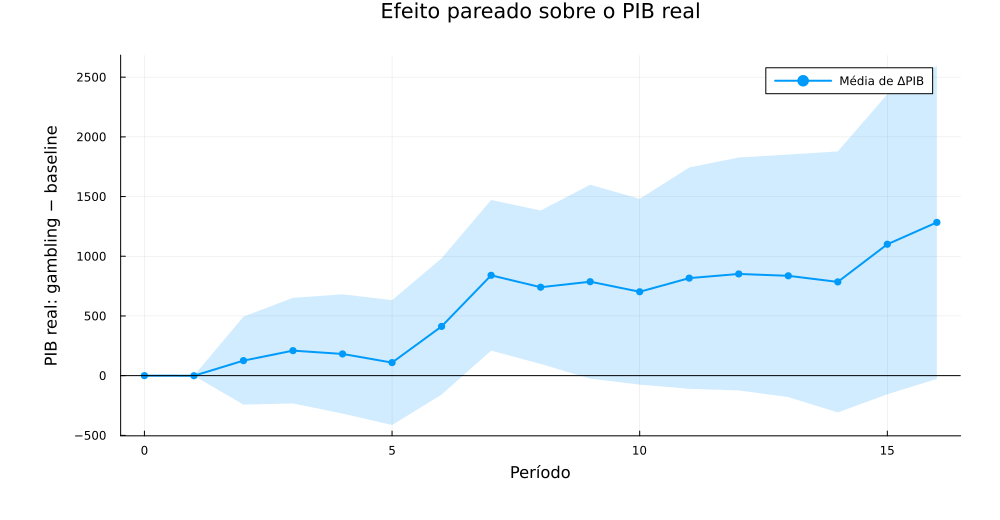

In [3]:
number_of_pairs = length(unique(paired.run))
t_critical = quantile(TDist(number_of_pairs - 1), 0.975)

gdp_by_period = combine(
    groupby(paired, :period),
    :delta_real_gdp => mean => :media,
    :delta_real_gdp => median => :mediana,
    :delta_real_gdp => std => :desvio_padrao,
    :delta_real_gdp => (x -> std(x) / sqrt(length(x))) => :erro_padrao,
    :delta_real_gdp => (x -> count(>(0), x)) => :pares_positivos,
)
transform!(gdp_by_period, [:media, :erro_padrao] => ByRow((m, se) -> m - t_critical * se) => :ic95_inferior)
transform!(gdp_by_period, [:media, :erro_padrao] => ByRow((m, se) -> m + t_critical * se) => :ic95_superior)

plot(
    gdp_by_period.period,
    gdp_by_period.media;
    ribbon = (
        gdp_by_period.media .- gdp_by_period.ic95_inferior,
        gdp_by_period.ic95_superior .- gdp_by_period.media,
    ),
    fillalpha = 0.18,
    marker = :circle,
    label = "Média de ΔPIB",
    xlabel = "Período",
    ylabel = "PIB real: gambling − baseline",
    title = "Efeito pareado sobre o PIB real",
)
hline!([0]; color = :black, linewidth = 1, label = false)

In [4]:
final_period = maximum(paired.period)
simulated_periods = filter(:period => >(0), paired)
mean_gdp_by_run = combine(
    groupby(simulated_periods, :run),
    :delta_real_gdp => mean => :delta_pib_medio,
)
final_gdp_by_run = select(
    filter(:period => ==(final_period), paired),
    :run, :delta_real_gdp => :delta_pib_final,
)
gdp_by_run = innerjoin(final_gdp_by_run, mean_gdp_by_run; on = :run)

gdp_summary = DataFrame(
    medida = String[], media = Float64[], mediana = Float64[],
    desvio_padrao = Float64[], ic95_inferior = Float64[],
    ic95_superior = Float64[], pares_positivos = Int[],
)
for (label, column) in [("PIB final", :delta_pib_final), ("PIB médio nos 16 períodos", :delta_pib_medio)]
    values = gdp_by_run[!, column]
    margin = t_critical * std(values) / sqrt(length(values))
    push!(gdp_summary, (
        label, mean(values), median(values), std(values),
        mean(values) - margin, mean(values) + margin, count(>(0), values),
    ))
end

gdp_summary

Row,medida,media,mediana,desvio_padrao,ic95_inferior,ic95_superior,pares_positivos
,String,Float64,Float64,Float64,Float64,Float64,Int64
1,PIB final,1283.77,992.485,2800.91,-27.0958,2594.64,14
2,PIB médio nos 16 períodos,611.426,630.544,1270.07,17.0138,1205.84,16


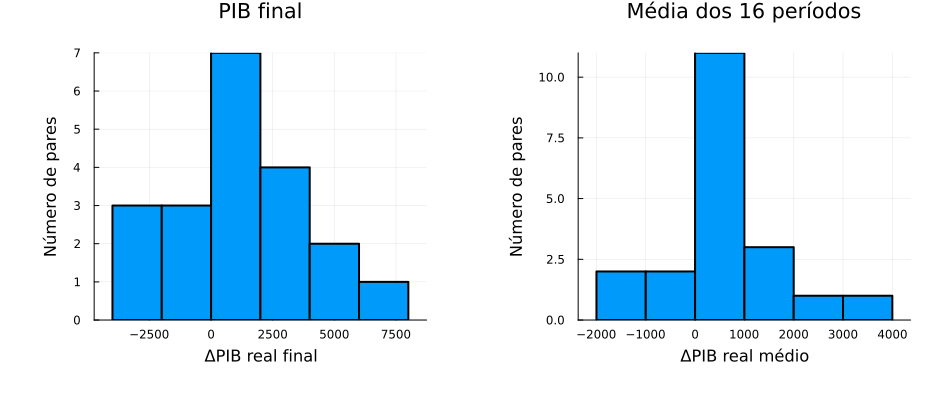

In [5]:
p_final = histogram(
    gdp_by_run.delta_pib_final; bins = 8, legend = false,
    xlabel = "ΔPIB real final", ylabel = "Número de pares", title = "PIB final",
)
vline!(p_final, [0]; color = :black, linewidth = 1)

p_mean = histogram(
    gdp_by_run.delta_pib_medio; bins = 8, legend = false,
    xlabel = "ΔPIB real médio", ylabel = "Número de pares", title = "Média dos 16 períodos",
)
vline!(p_mean, [0]; color = :black, linewidth = 1)

plot(p_final, p_mean; layout = (1, 2), size = (950, 400))

## 2. Efeito pareado sobre a desigualdade de renda

O índice de Gini é calculado em cada período sobre a renda disponível individual de trabalhadores ativos, inativos, proprietários de empresas e proprietário do banco, depois da transferência das apostas. O primeiro gráfico compara os níveis médios dos dois cenários. O segundo mostra `ΔGini = Gini com apostas − Gini baseline`: valores positivos indicam maior desigualdade no cenário com apostas.

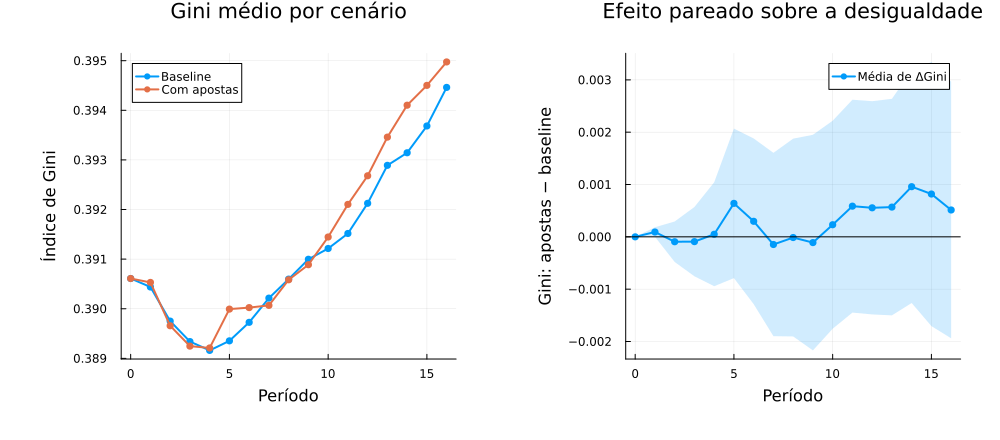

In [6]:
gini_by_period = combine(
    groupby(paired, :period),
    :baseline_household_income_gini => mean => :baseline,
    :gambling_household_income_gini => mean => :gambling,
    :delta_household_income_gini => mean => :delta_media,
    :delta_household_income_gini => (x -> std(x) / sqrt(length(x))) => :erro_padrao,
)
transform!(gini_by_period, [:delta_media, :erro_padrao] => ByRow((m, se) -> m - t_critical * se) => :ic95_inferior)
transform!(gini_by_period, [:delta_media, :erro_padrao] => ByRow((m, se) -> m + t_critical * se) => :ic95_superior)
@assert iszero(only(filter(:period => ==(0), gini_by_period).delta_media))

p_gini_levels = plot(
    gini_by_period.period, gini_by_period.baseline;
    marker = :circle, label = "Baseline", xlabel = "Período",
    ylabel = "Índice de Gini", title = "Gini médio por cenário",
)
plot!(p_gini_levels, gini_by_period.period, gini_by_period.gambling; marker = :circle, label = "Com apostas")

p_gini_delta = plot(
    gini_by_period.period, gini_by_period.delta_media;
    ribbon = (
        gini_by_period.delta_media .- gini_by_period.ic95_inferior,
        gini_by_period.ic95_superior .- gini_by_period.delta_media,
    ),
    fillalpha = 0.18, marker = :circle, label = "Média de ΔGini",
    xlabel = "Período", ylabel = "Gini: apostas − baseline",
    title = "Efeito pareado sobre a desigualdade",
)
hline!(p_gini_delta, [0]; color = :black, linewidth = 1, label = false)

plot(p_gini_levels, p_gini_delta; layout = (1, 2), size = (1000, 440))

In [7]:
mean_gini_by_run = combine(
    groupby(simulated_periods, :run),
    :delta_household_income_gini => mean => :delta_gini_medio,
)
final_gini_by_run = select(
    filter(:period => ==(final_period), paired),
    :run, :delta_household_income_gini => :delta_gini_final,
)
gini_by_run = innerjoin(final_gini_by_run, mean_gini_by_run; on = :run)

gini_summary = DataFrame(
    medida = String[], media = Float64[], mediana = Float64[],
    desvio_padrao = Float64[], ic95_inferior = Float64[],
    ic95_superior = Float64[], pares_com_aumento = Int[],
)
for (label, column) in [("Gini final", :delta_gini_final), ("Gini médio nos 16 períodos", :delta_gini_medio)]
    values = gini_by_run[!, column]
    margin = t_critical * std(values) / sqrt(length(values))
    push!(gini_summary, (
        label, mean(values), median(values), std(values),
        mean(values) - margin, mean(values) + margin, count(>(0), values),
    ))
end

gini_summary

Row,medida,media,mediana,desvio_padrao,ic95_inferior,ic95_superior,pares_com_aumento
,String,Float64,Float64,Float64,Float64,Float64,Int64
1,Gini final,0.000513396,0.00095639,0.00524064,-0.0019393,0.00296609,11
2,Gini médio nos 16 períodos,0.000303464,0.000476327,0.00314338,-0.00116768,0.00177461,13


## 3. Redistribuição e resposta do mercado

Esta seção acompanha o caminho entre a renda dos grupos e os resultados do mercado. As diferenças dos apostadores e dos proprietários beneficiados são apresentadas por agente, pois os dois grupos têm tamanhos distintos. Orçamentos desejados, quantidades realizadas e valores reais ou nominais permanecem separados; seus níveis não devem ser comparados diretamente.

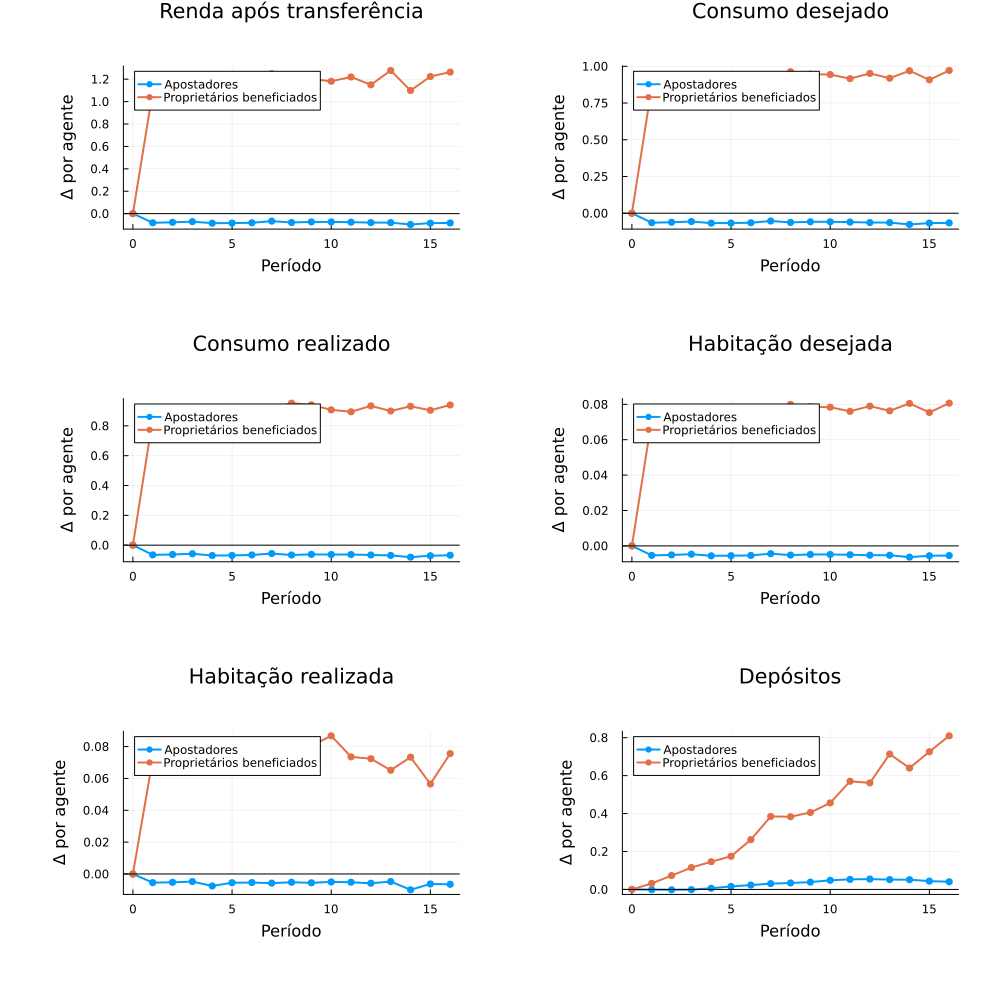

In [8]:
paired.delta_gambler_income_per_agent = paired.delta_gambler_income_post ./ paired.gambler_count
paired.delta_owner_income_per_agent = paired.delta_recipient_owner_income_post ./ paired.recipient_owner_count
paired.delta_gambler_consumption_desired_per_agent = paired.delta_gambler_consumption_desired ./ paired.gambler_count
paired.delta_owner_consumption_desired_per_agent = paired.delta_recipient_owner_consumption_desired ./ paired.recipient_owner_count
paired.delta_gambler_consumption_realized_per_agent = paired.delta_gambler_consumption_realized ./ paired.gambler_count
paired.delta_owner_consumption_realized_per_agent = paired.delta_recipient_owner_consumption_realized ./ paired.recipient_owner_count
paired.delta_gambler_housing_desired_per_agent = paired.delta_gambler_housing_desired ./ paired.gambler_count
paired.delta_owner_housing_desired_per_agent = paired.delta_recipient_owner_housing_desired ./ paired.recipient_owner_count
paired.delta_gambler_housing_realized_per_agent = paired.delta_gambler_housing_realized ./ paired.gambler_count
paired.delta_owner_housing_realized_per_agent = paired.delta_recipient_owner_housing_realized ./ paired.recipient_owner_count
paired.delta_gambler_deposits_per_agent = paired.delta_gambler_deposits ./ paired.gambler_count
paired.delta_owner_deposits_per_agent = paired.delta_recipient_owner_deposits ./ paired.recipient_owner_count

simulated_periods = filter(:period => >(0), paired)

group_effects_by_period = combine(
    groupby(paired, :period),
    :delta_gambler_income_per_agent => mean => :gambler_income,
    :delta_owner_income_per_agent => mean => :owner_income,
    :delta_gambler_consumption_desired_per_agent => mean => :gambler_consumption_desired,
    :delta_owner_consumption_desired_per_agent => mean => :owner_consumption_desired,
    :delta_gambler_consumption_realized_per_agent => mean => :gambler_consumption_realized,
    :delta_owner_consumption_realized_per_agent => mean => :owner_consumption_realized,
    :delta_gambler_housing_desired_per_agent => mean => :gambler_housing_desired,
    :delta_owner_housing_desired_per_agent => mean => :owner_housing_desired,
    :delta_gambler_housing_realized_per_agent => mean => :gambler_housing_realized,
    :delta_owner_housing_realized_per_agent => mean => :owner_housing_realized,
    :delta_gambler_deposits_per_agent => mean => :gambler_deposits,
    :delta_owner_deposits_per_agent => mean => :owner_deposits,
)

function group_panel(data, gambler_column, owner_column, title)
    panel = plot(
        data.period, data[!, gambler_column]; marker = :circle,
        label = "Apostadores", title = title, ylabel = "Δ por agente",
    )
    plot!(panel, data.period, data[!, owner_column]; marker = :circle, label = "Proprietários beneficiados")
    hline!(panel, [0]; color = :black, linewidth = 1, label = false)
    return panel
end

group_panels = [
    group_panel(group_effects_by_period, :gambler_income, :owner_income, "Renda após transferência"),
    group_panel(group_effects_by_period, :gambler_consumption_desired, :owner_consumption_desired, "Consumo desejado"),
    group_panel(group_effects_by_period, :gambler_consumption_realized, :owner_consumption_realized, "Consumo realizado"),
    group_panel(group_effects_by_period, :gambler_housing_desired, :owner_housing_desired, "Habitação desejada"),
    group_panel(group_effects_by_period, :gambler_housing_realized, :owner_housing_realized, "Habitação realizada"),
    group_panel(group_effects_by_period, :gambler_deposits, :owner_deposits, "Depósitos"),
]
plot(group_panels...; layout = (3, 2), size = (1000, 1000), xlabel = "Período")

In [9]:
group_horizon = DataFrame(
    grupo = ["Apostadores", "Demais trabalhadores", "Proprietários beneficiados", "Demais proprietários"],
    delta_renda = mean.([
        simulated_periods.delta_gambler_income_post, simulated_periods.delta_other_worker_income,
        simulated_periods.delta_recipient_owner_income_post, simulated_periods.delta_other_owner_income,
    ]),
    delta_consumo_desejado = mean.([
        simulated_periods.delta_gambler_consumption_desired, simulated_periods.delta_other_worker_consumption_desired,
        simulated_periods.delta_recipient_owner_consumption_desired, simulated_periods.delta_other_owner_consumption_desired,
    ]),
    delta_consumo_realizado = mean.([
        simulated_periods.delta_gambler_consumption_realized, simulated_periods.delta_other_worker_consumption_realized,
        simulated_periods.delta_recipient_owner_consumption_realized, simulated_periods.delta_other_owner_consumption_realized,
    ]),
    delta_habitacao_desejada = mean.([
        simulated_periods.delta_gambler_housing_desired, simulated_periods.delta_other_worker_housing_desired,
        simulated_periods.delta_recipient_owner_housing_desired, simulated_periods.delta_other_owner_housing_desired,
    ]),
    delta_habitacao_realizada = mean.([
        simulated_periods.delta_gambler_housing_realized, simulated_periods.delta_other_worker_housing_realized,
        simulated_periods.delta_recipient_owner_housing_realized, simulated_periods.delta_other_owner_housing_realized,
    ]),
    delta_depositos = mean.([
        simulated_periods.delta_gambler_deposits, simulated_periods.delta_other_worker_deposits,
        simulated_periods.delta_recipient_owner_deposits, simulated_periods.delta_other_owner_deposits,
    ]),
)
group_horizon

Row,grupo,delta_renda,delta_consumo_desejado,delta_consumo_realizado,delta_habitacao_desejada,delta_habitacao_realizada,delta_depositos
,String,Float64,Float64,Float64,Float64,Float64,Float64
1,Apostadores,-66.0707,-52.133,-54.1837,-4.32838,-4.83238,25.2108
2,Demais trabalhadores,30.0864,23.7396,4.26208,1.971,-2.81676,332.103
3,Proprietários beneficiados,72.2742,56.6878,55.7879,4.70654,4.46245,25.0153
4,Demais proprietários,48.4901,35.3596,30.3306,2.93576,1.2422,114.614


In [10]:
market_metrics = [
    ("Consumo desejado das famílias", :delta_household_consumption_desired),
    ("Consumo realizado das famílias", :delta_household_consumption_realized),
    ("Habitação desejada das famílias", :delta_household_housing_desired),
    ("Habitação realizada das famílias", :delta_household_housing_realized),
    ("Vendas das empresas", :delta_firm_sales),
    ("Receita nominal das empresas", :delta_firm_revenue),
    ("Lucro das empresas", :delta_firm_profit),
    ("Produção realizada", :delta_firm_output_realized),
    ("Emprego realizado", :delta_firm_employment_realized),
    ("Investimento realizado", :delta_firm_investment_realized),
    ("Estoque de produtos acabados", :delta_firm_finished_goods_stock),
    ("Importações reais", :delta_real_imports),
]

market_summary = DataFrame(
    variavel = String[], medida = String[], media = Float64[],
    ic95_inferior = Float64[], ic95_superior = Float64[], pares_positivos = Int[],
)
for (label, column) in market_metrics
    average_by_run = combine(groupby(simulated_periods, :run), column => mean => :effect)
    final_values = filter(:period => ==(final_period), paired)[!, column]
    for (measure, values) in [("Média dos 16 períodos", average_by_run.effect), ("Período final", final_values)]
        margin = t_critical * std(values) / sqrt(length(values))
        push!(market_summary, (
            label, measure, mean(values), mean(values) - margin,
            mean(values) + margin, count(>(0), values),
        ))
    end
end
market_summary

Row,variavel,medida,media,ic95_inferior,ic95_superior,pares_positivos
,String,String,Float64,Float64,Float64,Int64
1,Consumo desejado das famílias,Média dos 16 períodos,67.1886,-316.477,450.854,9
2,Consumo desejado das famílias,Período final,127.922,-628.677,884.52,11
3,Consumo realizado das famílias,Média dos 16 períodos,37.0018,-352.186,426.189,9
4,Consumo realizado das famílias,Período final,110.223,-664.862,885.308,11
5,Habitação desejada das famílias,Média dos 16 períodos,5.57838,-26.2758,37.4325,9
6,Habitação desejada das famílias,Período final,10.6208,-52.1964,73.438,11
7,Habitação realizada das famílias,Média dos 16 períodos,-2.52789,-36.7596,31.7039,10
8,Habitação realizada das famílias,Período final,8.54381,-63.4274,80.5151,11
9,Vendas das empresas,Média dos 16 períodos,1381.83,191.212,2572.44,16


## 4. Decomposição contábil do PIB

A diferença do PIB deve ser reconciliada pela identidade:

$$
\Delta PIB = \Delta C + \Delta G + \Delta I + \Delta X - \Delta M.
$$

Essa decomposição identifica o componente contábil associado ao resultado; ela ainda não demonstra, sozinha, o mecanismo econômico.

┌ Warning: Keyword argument bar_position not supported with Plots.GRBackend().  Choose from: annotationcolor, annotationfontfamily, annotationfontsize, annotationhalign, annotationrotation, annotations, annotationvalign, arrow, aspect_ratio, axis, background_color, background_color_inside, background_color_outside, background_color_subplot, bar_width, bins, bottom_margin, camera, clims, color_palette, colorbar, colorbar_entry, colorbar_scale, colorbar_title, colorbar_titlefont, colorbar_titlefontcolor, colorbar_titlefontrotation, colorbar_titlefontsize, connections, contour_labels, discrete_values, fill, fill_z, fillalpha, fillcolor, fillrange, fillstyle, flip, fontfamily, fontfamily_subplot, foreground_color, foreground_color_axis, foreground_color_border, foreground_color_grid, foreground_color_subplot, foreground_color_text, formatter, framestyle, grid, gridalpha, gridlinewidth, gridstyle, group, guide, guidefont, guidefontcolor, guidefontfamily, guidefonthalign, guidefontrotation, 

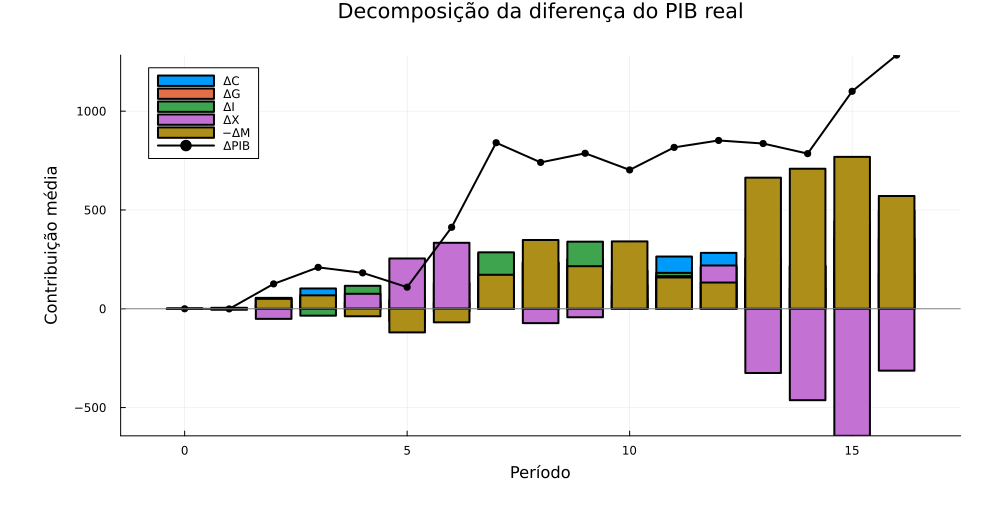

In [11]:
paired.delta_real_gdp_from_components =
    paired.delta_real_household_consumption .+
    paired.delta_real_government_consumption .+
    paired.delta_real_capitalformation .+
    paired.delta_real_exports .-
    paired.delta_real_imports
paired.delta_real_gdp_reconciliation_residual =
    paired.delta_real_gdp .- paired.delta_real_gdp_from_components

@assert maximum(abs.(paired.delta_real_gdp_reconciliation_residual)) < 1e-6

gdp_components_by_period = combine(
    groupby(paired, :period),
    :delta_real_household_consumption => mean => :delta_C,
    :delta_real_government_consumption => mean => :delta_G,
    :delta_real_capitalformation => mean => :delta_I,
    :delta_real_exports => mean => :delta_X,
    :delta_real_imports => (x -> -mean(x)) => :menos_delta_M,
    :delta_real_gdp => mean => :delta_PIB,
)

component_matrix = Matrix(select(
    gdp_components_by_period, :delta_C, :delta_G, :delta_I, :delta_X, :menos_delta_M,
))
bar(
    gdp_components_by_period.period, component_matrix;
    bar_position = :stack, label = ["ΔC" "ΔG" "ΔI" "ΔX" "−ΔM"],
    xlabel = "Período", ylabel = "Contribuição média",
    title = "Decomposição da diferença do PIB real",
)
plot!(
    gdp_components_by_period.period, gdp_components_by_period.delta_PIB;
    color = :black, marker = :circle, label = "ΔPIB",
)
hline!([0]; color = :gray, linewidth = 1, label = false)

In [12]:
component_horizon = DataFrame(
    componente = ["ΔC", "ΔG", "ΔI", "ΔX", "−ΔM"],
    contribuicao_media = [
        mean(simulated_periods.delta_real_household_consumption),
        mean(simulated_periods.delta_real_government_consumption),
        mean(simulated_periods.delta_real_capitalformation),
        mean(simulated_periods.delta_real_exports),
        -mean(simulated_periods.delta_real_imports),
    ],
)
component_horizon.magnitude = abs.(component_horizon.contribuicao_media)
sort!(component_horizon, :magnitude, rev = true)
select(component_horizon, Not(:magnitude))

Row,componente,contribuicao_media
,String,Float64
1,−ΔM,248.221
2,ΔC,195.784
3,ΔI,164.478
4,ΔG,42.4518
5,ΔX,-39.5087


## 5. Propagação para as empresas

As trajetórias seguintes procuram a sequência `gasto realizado → vendas e lucros → produção e emprego`. Como a produção ocorre antes da transferência dentro do passo do modelo, também examinamos associações com o período seguinte.

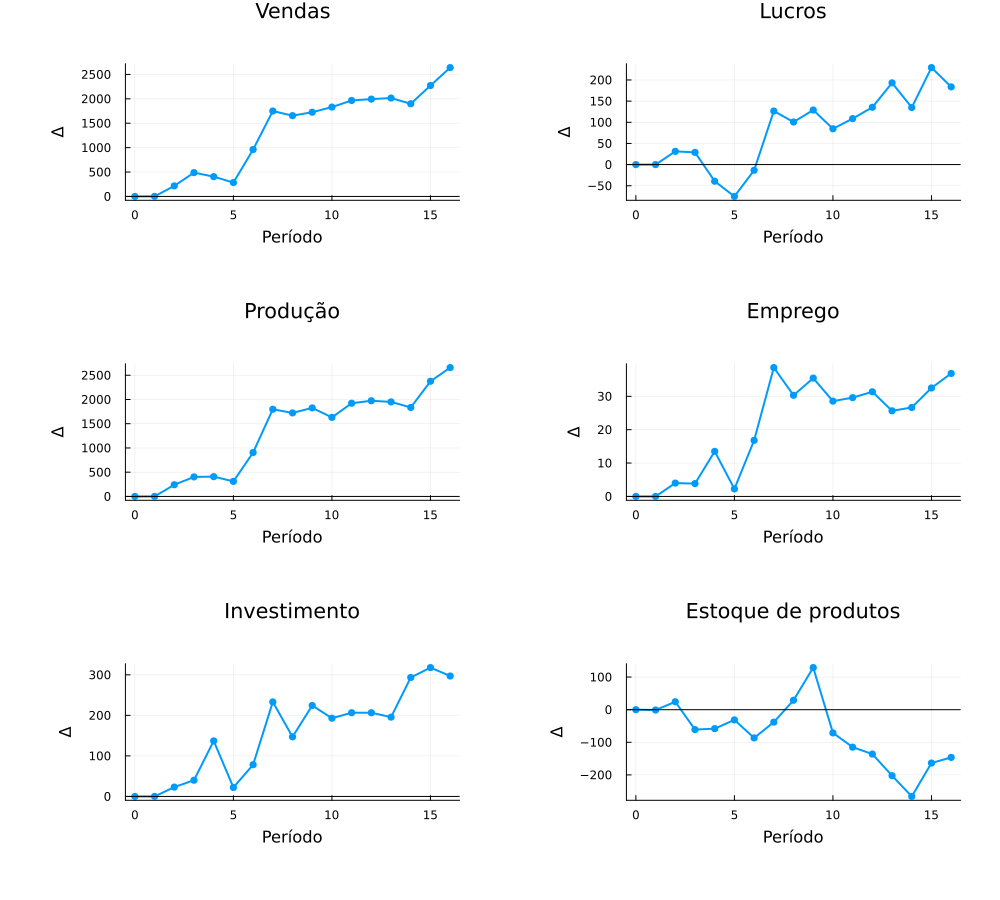

In [13]:
firm_by_period = combine(
    groupby(paired, :period),
    :delta_firm_sales => mean => :vendas,
    :delta_firm_profit => mean => :lucros,
    :delta_firm_output_realized => mean => :producao,
    :delta_firm_employment_realized => mean => :emprego,
    :delta_firm_investment_realized => mean => :investimento,
    :delta_firm_finished_goods_stock => mean => :estoque_produtos,
)

p_sales = plot(firm_by_period.period, firm_by_period.vendas; marker = :circle, label = false, title = "Vendas", ylabel = "Δ")
p_profit = plot(firm_by_period.period, firm_by_period.lucros; marker = :circle, label = false, title = "Lucros", ylabel = "Δ")
p_output = plot(firm_by_period.period, firm_by_period.producao; marker = :circle, label = false, title = "Produção", ylabel = "Δ")
p_employment = plot(firm_by_period.period, firm_by_period.emprego; marker = :circle, label = false, title = "Emprego", ylabel = "Δ")
p_investment = plot(firm_by_period.period, firm_by_period.investimento; marker = :circle, label = false, title = "Investimento", ylabel = "Δ")
p_inventory = plot(firm_by_period.period, firm_by_period.estoque_produtos; marker = :circle, label = false, title = "Estoque de produtos", ylabel = "Δ")
for panel in (p_sales, p_profit, p_output, p_employment, p_investment, p_inventory)
    hline!(panel, [0]; color = :black, linewidth = 1, label = false)
end
plot(
    p_sales, p_profit, p_output, p_employment, p_investment, p_inventory;
    layout = (3, 2), size = (1000, 900), xlabel = "Período",
)

In [14]:
current_effects = select(
    filter(row -> 1 <= row.period < final_period, paired),
    :run, :period, :delta_household_consumption_realized,
    :delta_firm_sales, :delta_firm_profit,
)
next_effects = select(
    filter(row -> 2 <= row.period <= final_period, paired),
    :run,
    :period => ByRow(period -> period - 1) => :period,
    :delta_firm_output_realized => :delta_output_next,
    :delta_firm_employment_realized => :delta_employment_next,
    :delta_firm_investment_realized => :delta_investment_next,
)
lagged_effects = innerjoin(current_effects, next_effects; on = [:run, :period])

lagged_summary = DataFrame(
    relacao = [
        "Δ consumo realizado(t) × Δ vendas(t)",
        "Δ consumo realizado(t) × Δ lucro(t)",
        "Δ vendas(t) × Δ produção(t+1)",
        "Δ vendas(t) × Δ emprego(t+1)",
        "Δ vendas(t) × Δ investimento(t+1)",
    ],
    correlacao = [
        cor(lagged_effects.delta_household_consumption_realized, lagged_effects.delta_firm_sales),
        cor(lagged_effects.delta_household_consumption_realized, lagged_effects.delta_firm_profit),
        cor(lagged_effects.delta_firm_sales, lagged_effects.delta_output_next),
        cor(lagged_effects.delta_firm_sales, lagged_effects.delta_employment_next),
        cor(lagged_effects.delta_firm_sales, lagged_effects.delta_investment_next),
    ],
)
lagged_summary

Row,relacao,correlacao
,String,Float64
1,Δ consumo realizado(t) × Δ vendas(t),0.655219
2,Δ consumo realizado(t) × Δ lucro(t),0.795969
3,Δ vendas(t) × Δ produção(t+1),0.928278
4,Δ vendas(t) × Δ emprego(t+1),0.800352
5,Δ vendas(t) × Δ investimento(t+1),0.821194


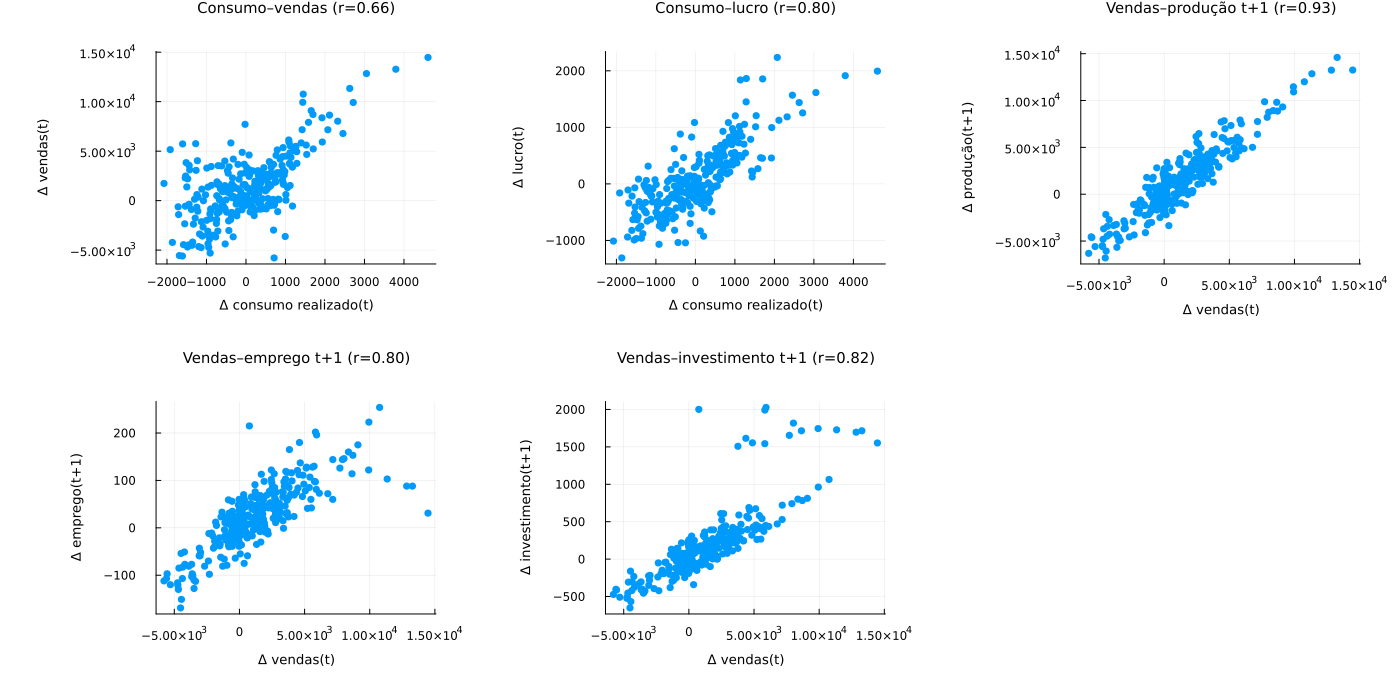

In [15]:
p_consumption_sales = scatter(
    lagged_effects.delta_household_consumption_realized, lagged_effects.delta_firm_sales;
    label = false, xlabel = "Δ consumo realizado(t)", ylabel = "Δ vendas(t)",
    title = @sprintf("Consumo–vendas (r=%.2f)", lagged_summary.correlacao[1]),
)
p_consumption_profit = scatter(
    lagged_effects.delta_household_consumption_realized, lagged_effects.delta_firm_profit;
    label = false, xlabel = "Δ consumo realizado(t)", ylabel = "Δ lucro(t)",
    title = @sprintf("Consumo–lucro (r=%.2f)", lagged_summary.correlacao[2]),
)
p_sales_output = scatter(
    lagged_effects.delta_firm_sales, lagged_effects.delta_output_next;
    label = false, xlabel = "Δ vendas(t)", ylabel = "Δ produção(t+1)",
    title = @sprintf("Vendas–produção t+1 (r=%.2f)", lagged_summary.correlacao[3]),
)
p_sales_employment = scatter(
    lagged_effects.delta_firm_sales, lagged_effects.delta_employment_next;
    label = false, xlabel = "Δ vendas(t)", ylabel = "Δ emprego(t+1)",
    title = @sprintf("Vendas–emprego t+1 (r=%.2f)", lagged_summary.correlacao[4]),
)
p_sales_investment = scatter(
    lagged_effects.delta_firm_sales, lagged_effects.delta_investment_next;
    label = false, xlabel = "Δ vendas(t)", ylabel = "Δ investimento(t+1)",
    title = @sprintf("Vendas–investimento t+1 (r=%.2f)", lagged_summary.correlacao[5]),
)
plot(
    p_consumption_sales, p_consumption_profit, p_sales_output,
    p_sales_employment, p_sales_investment;
    layout = (2, 3), size = (1400, 700),
    titlefontsize = 10, guidefontsize = 9, tickfontsize = 8,
)

As correlações acima são descritivas. Elas ajudam a localizar uma sequência temporal compatível com o mecanismo, mas não devem ser interpretadas isoladamente como prova causal.

In [16]:
evidence_table = DataFrame(
    elo = [
        "Apostas pagas = recebimentos dos proprietários",
        "Redistribuição → consumo desejado dos grupos",
        "Consumo realizado(t) → vendas e lucro(t)",
        "Vendas(t) → produção, emprego e investimento(t+1)",
        "Redistribuição → escolha entre fornecedor nacional e importado",
    ],
    evidencia = [
        @sprintf("resíduo máximo = %.2e", maximum(abs.(gambling_trace.transfer_residual))),
        @sprintf("Δ por agente: apostadores %.3f; beneficiários %+.3f", mean(simulated_periods.delta_gambler_consumption_desired_per_agent), mean(simulated_periods.delta_owner_consumption_desired_per_agent)),
        @sprintf("correlações: vendas %.2f; lucro %.2f", lagged_summary.correlacao[1], lagged_summary.correlacao[2]),
        @sprintf("correlações: produção %.2f; emprego %.2f; investimento %.2f", lagged_summary.correlacao[3], lagged_summary.correlacao[4], lagged_summary.correlacao[5]),
        "O CSV registra apenas importações agregadas",
    ],
    leitura = [
        "Suportado contabilmente",
        "Compatível com a redistribuição",
        "Associação descritiva",
        "Associação descritiva",
        "Não observável com os dados atuais",
    ],
)
evidence_table

Row,elo,evidencia,leitura
,String,String,String
1,Apostas pagas = recebimentos dos proprietários,resíduo máximo = 2.84e-14,Suportado contabilmente
2,Redistribuição → consumo desejado dos grupos,Δ por agente: apostadores -0.063; beneficiários +0.914,Compatível com a redistribuição
3,Consumo realizado(t) → vendas e lucro(t),correlações: vendas 0.66; lucro 0.80,Associação descritiva
4,"Vendas(t) → produção, emprego e investimento(t+1)",correlações: produção 0.93; emprego 0.80; investimento 0.82,Associação descritiva
5,Redistribuição → escolha entre fornecedor nacional e importado,O CSV registra apenas importações agregadas,Não observável com os dados atuais


## 6. Origem das compras das famílias

A instrumentação do *search and match* permite observar quanto cada grupo comprou de fornecedores nacionais e estrangeiros. O valor registrado combina consumo e investimento habitacional, pois ambos entram juntos no mercado varejista do modelo. O preço médio implícito é a despesa nominal dividida pela quantidade adquirida.

Row,grupo,delta_despesa_nacional,delta_despesa_importada,delta_demanda_nao_atendida,delta_preco_nacional,delta_preco_importado
,String,Float64,Float64,Float64,Float64,Float64
1,Trabalhadores participantes,-45.8477,-13.1684,2.55473,-0.003884,-0.003884
2,Outros trabalhadores,57.3187,-55.8734,24.2653,-0.003884,-0.003884
3,Proprietários beneficiados,56.0837,4.16661,1.144,-0.003884,-0.003884
4,Outros proprietários,42.1505,-10.5777,6.72261,-0.003884,-0.003884
5,Proprietário do banco,2.32537,-2.10385,3.60647,-0.003884,-0.003884


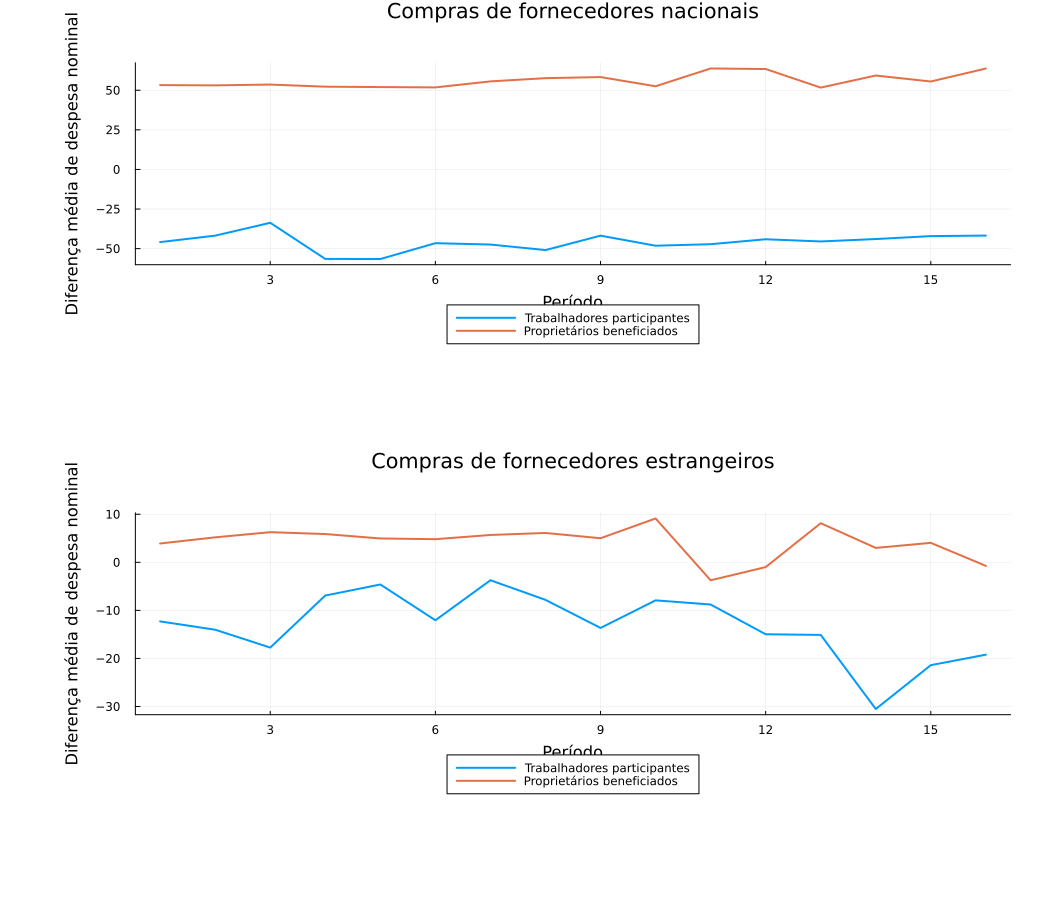

In [17]:
origin_groups = [
    (prefix = "gambler", label = "Trabalhadores participantes", count = gambling_trace.active_gamblers .+ gambling_trace.inactive_gamblers),
    (prefix = "other_worker", label = "Outros trabalhadores", count = ones(nrow(gambling_trace))),
    (prefix = "recipient_owner", label = "Proprietários beneficiados", count = gambling_trace.recipient_owners),
    (prefix = "other_owner", label = "Outros proprietários", count = ones(nrow(gambling_trace))),
    (prefix = "bank", label = "Proprietário do banco", count = ones(nrow(gambling_trace))),
]

origin_rows = NamedTuple[]
origin_period_rows = NamedTuple[]
for group in origin_groups
    domestic_exp = Symbol(group.prefix, "_domestic_purchase_expenditure")
    imported_exp = Symbol(group.prefix, "_imported_purchase_expenditure")
    domestic_qty = Symbol(group.prefix, "_domestic_purchase_quantity")
    imported_qty = Symbol(group.prefix, "_imported_purchase_quantity")
    unfilled = Symbol(group.prefix, "_unfilled_purchase_demand")
    simulated = gambling_trace.period .> 0
    delta_domestic = gambling_trace[simulated, domestic_exp] .- baseline_trace[simulated, domestic_exp]
    delta_imported = gambling_trace[simulated, imported_exp] .- baseline_trace[simulated, imported_exp]
    delta_unfilled = gambling_trace[simulated, unfilled] .- baseline_trace[simulated, unfilled]
    domestic_valid = (gambling_trace[simulated, domestic_qty] .> 0) .& (baseline_trace[simulated, domestic_qty] .> 0)
    imported_valid = (gambling_trace[simulated, imported_qty] .> 0) .& (baseline_trace[simulated, imported_qty] .> 0)
    domestic_price_change = gambling_trace[simulated, domestic_exp][domestic_valid] ./ gambling_trace[simulated, domestic_qty][domestic_valid] .- baseline_trace[simulated, domestic_exp][domestic_valid] ./ baseline_trace[simulated, domestic_qty][domestic_valid]
    imported_price_change = gambling_trace[simulated, imported_exp][imported_valid] ./ gambling_trace[simulated, imported_qty][imported_valid] .- baseline_trace[simulated, imported_exp][imported_valid] ./ baseline_trace[simulated, imported_qty][imported_valid]
    push!(origin_rows, (
        grupo = group.label,
        delta_despesa_nacional = mean(delta_domestic),
        delta_despesa_importada = mean(delta_imported),
        delta_demanda_nao_atendida = mean(delta_unfilled),
        delta_preco_nacional = isempty(domestic_price_change) ? missing : mean(domestic_price_change),
        delta_preco_importado = isempty(imported_price_change) ? missing : mean(imported_price_change),
    ))
    for period in 1:final_period
        rows = gambling_trace.period .== period
        push!(origin_period_rows, (
            periodo = period,
            grupo = group.label,
            delta_nacional = mean(gambling_trace[rows, domestic_exp] - baseline_trace[rows, domestic_exp]),
            delta_importada = mean(gambling_trace[rows, imported_exp] - baseline_trace[rows, imported_exp]),
        ))
    end
end
origin_summary = DataFrame(origin_rows)
origin_by_period = DataFrame(origin_period_rows)
display(origin_summary)

treated_origin = filter(:grupo => in(["Trabalhadores participantes", "Proprietários beneficiados"]), origin_by_period)
p_origin_domestic = plot(
    xlabel = "Período", ylabel = "Diferença média de despesa nominal",
    title = "Compras de fornecedores nacionais", legend = :outerbottom,
)
p_origin_imported = plot(
    xlabel = "Período", ylabel = "Diferença média de despesa nominal",
    title = "Compras de fornecedores estrangeiros", legend = :outerbottom,
)
for group in unique(treated_origin.grupo)
    rows = treated_origin.grupo .== group
    plot!(p_origin_domestic, treated_origin.periodo[rows], treated_origin.delta_nacional[rows]; label = group)
    plot!(p_origin_imported, treated_origin.periodo[rows], treated_origin.delta_importada[rows]; label = group)
end
plot(p_origin_domestic, p_origin_imported; layout = (2, 1), size = (1050, 900), left_margin = 18 * Plots.mm, bottom_margin = 14 * Plots.mm)

## 7. Conclusão provisória e limites

A célula seguinte resume automaticamente os principais números. A conclusão final deve distinguir a diferença observada no PIB da interpretação do mecanismo econômico sugerido pelas variáveis intermediárias.

In [18]:
final_result = gdp_summary[1, :]
average_result = gdp_summary[2, :]
gini_final_result = gini_summary[1, :]
gini_average_result = gini_summary[2, :]
dominant_component = component_horizon[1, :]
final_interval = final_result.ic95_inferior > 0 ?
    "inteiramente acima de zero" :
    final_result.ic95_superior < 0 ? "inteiramente abaixo de zero" : "inclui zero"
average_interval = average_result.ic95_inferior > 0 ?
    "inteiramente acima de zero" :
    average_result.ic95_superior < 0 ? "inteiramente abaixo de zero" : "inclui zero"
gini_final_interval = gini_final_result.ic95_inferior > 0 ?
    "inteiramente acima de zero" :
    gini_final_result.ic95_superior < 0 ? "inteiramente abaixo de zero" : "inclui zero"
gini_average_interval = gini_average_result.ic95_inferior > 0 ?
    "inteiramente acima de zero" :
    gini_average_result.ic95_superior < 0 ? "inteiramente abaixo de zero" : "inclui zero"

display(MIME"text/markdown"(), Markdown.parse("""
### Leitura dos resultados atuais

- A diferença média do **PIB real final** foi de **$(@sprintf("%.1f", final_result.media))**, positiva em **$(final_result.pares_positivos) de $number_of_pairs pares**. Seu intervalo de 95% **$final_interval**.
- A diferença do **PIB real médio ao longo dos 16 períodos** foi de **$(@sprintf("%.1f", average_result.media))**, positiva em **$(average_result.pares_positivos) de $number_of_pairs pares**. Seu intervalo de 95% **$average_interval**.
- A diferença média do **Gini da renda no período final** foi de **$(@sprintf("%+.6f", gini_final_result.media))**, com aumento em **$(gini_final_result.pares_com_aumento) de $number_of_pairs pares**. Seu intervalo de 95% **$gini_final_interval**.
- A diferença do **Gini médio ao longo dos 16 períodos** foi de **$(@sprintf("%+.6f", gini_average_result.media))**, com aumento em **$(gini_average_result.pares_com_aumento) de $number_of_pairs pares**. Seu intervalo de 95% **$gini_average_interval**.
- O **consumo desejado por apostador** mudou em média **$(@sprintf("%+.3f", mean(simulated_periods.delta_gambler_consumption_desired_per_agent)))** por período, enquanto o dos **proprietários beneficiados** mudou **$(@sprintf("%+.3f", mean(simulated_periods.delta_owner_consumption_desired_per_agent)))** por beneficiário.
- O componente com maior contribuição média em valor absoluto foi **$(dominant_component.componente)**, com **$(@sprintf("%.1f", dominant_component.contribuicao_media))**.

Esses resultados devem ser apresentados como evidência exploratória de 20 pares. Uma diferença positiva do PIB não basta para afirmar o mecanismo: a interpretação depende também da distribuição da renda, da decomposição contábil, dos resultados das empresas e das defasagens temporais.
"""))

### Leitura dos resultados atuais

  * A diferença média do **PIB real final** foi de **1283.8**, positiva em **14 de 20 pares**. Seu intervalo de 95% **inclui zero**.
  * A diferença do **PIB real médio ao longo dos 16 períodos** foi de **611.4**, positiva em **16 de 20 pares**. Seu intervalo de 95% **inteiramente acima de zero**.
  * A diferença média do **Gini da renda no período final** foi de **+0.000513**, com aumento em **11 de 20 pares**. Seu intervalo de 95% **inclui zero**.
  * A diferença do **Gini médio ao longo dos 16 períodos** foi de **+0.000303**, com aumento em **13 de 20 pares**. Seu intervalo de 95% **inclui zero**.
  * O **consumo desejado por apostador** mudou em média **-0.063** por período, enquanto o dos **proprietários beneficiados** mudou **+0.914** por beneficiário.
  * O componente com maior contribuição média em valor absoluto foi **−ΔM**, com **248.2**.

Esses resultados devem ser apresentados como evidência exploratória de 20 pares. Uma diferença positiva do PIB não basta para afirmar o mecanismo: a interpretação depende também da distribuição da renda, da decomposição contábil, dos resultados das empresas e das defasagens temporais.


### Limitações

1. O experimento possui apenas 20 pares e deve ser interpretado como exploratório.
2. O mecanismo representa uma transferência estilizada; não há produção de serviços de apostas, tributação específica ou operadores de apostas.
3. O Gini mede a desigualdade da renda disponível após a transferência; não mede patrimônio, consumo ou bem-estar.
4. A origem nacional ou estrangeira agora é observável por grupo, mas o agregado combina consumo e investimento habitacional e não identifica o produto ou a empresa escolhida.
5. As correlações contemporâneas e defasadas descrevem associações dentro das simulações, não identificação causal adicional.
6. Se a conclusão depender de um efeito pequeno ou instável, o experimento deve ser repetido com mais sementes e, posteriormente, com outras parcelas de renda e taxas de participação.